# ML Training — CIC-IDS-2018 (Fixed Pipeline)

| # | Fix Applied | Details |
|---|-------------|---------|
| 1 | **Corrupt rows removed** | Negative values in time/duration features are physically impossible (CICFlowMeter bug) |
| 2 | **Correct scaling order** | Split train/test FIRST → fit scalers on train only → transform both |
| 3 | **Honest metrics** | Balanced Accuracy + per-class Recall replace plain accuracy as primary metric |

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, balanced_accuracy_score  
)

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

print('=' * 80)
print('🚀 ML TRAINING — CIC-IDS-2018 FIXED PIPELINE')
print('=' * 80)

🚀 ML TRAINING — CIC-IDS-2018 FIXED PIPELINE


## 2. Configuration

In [5]:
INPUT_FILE     = 'archive/full_df_binary_labels.csv'
BASE_MODEL_DIR = 'trained_models/ml_fixed/'
TEST_SIZE      = 0.2
RANDOM_STATE   = 42
SAVE_MODELS    = True

# Features that are physically impossible to be negative
# (time durations, packet counts, byte counts)
NON_NEGATIVE_FEATURES = [
    'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std',
    'Flow IAT Max',  'Flow IAT Min',  'Fwd IAT Tot',
    'Fwd IAT Mean',  'Fwd IAT Std',   'Fwd IAT Max',
    'Fwd IAT Min',   'Bwd IAT Tot',   'Bwd IAT Mean',
    'Bwd IAT Std',   'Bwd IAT Max',   'Bwd IAT Min',
    'Idle Mean',     'Idle Max',      'Idle Min',
    'Tot Fwd Pkts',  'Tot Bwd Pkts',  'TotLen Fwd Pkts',
    'TotLen Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s'
]

# Features to apply PowerTransformer (extreme skew)
POWER_TRANSFORMER_FEATURES = [
    'Dst Port', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
    'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max',
    'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s',
    'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
    'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std',
    'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean',
    'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Len',
    'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Max',
    'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'Down/Up Ratio',
    'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
    'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts',
    'Subflow Bwd Byts', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Fwd Act Data Pkts', 'Idle Mean', 'Idle Max', 'Idle Min'
]

# Features for StandardScaler (low skew)
STANDARD_SCALER_FEATURES = ['Fwd Seg Size Min']

# Features to leave unscaled (binary/categorical flags)
NO_SCALING_FEATURES = [
    'Protocol', 'RST Flag Cnt', 'PSH Flag Cnt',
    'ACK Flag Cnt', 'URG Flag Cnt', 'ECE Flag Cnt'
]

# Per-model sample sizes (None = use full dataset)
MODEL_SAMPLE_SIZES = {
    'Random Forest':      None,
    'Decision Tree':      None,
    'Logistic Regression': None,
    'XGBoost':            None,
    'LightGBM':           None,
    'KNN':                50000,
    'Naive Bayes':        None,
    'SVM':                100000
}

os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print('✅ Configuration set')
print(f'   Output directory: {BASE_MODEL_DIR}')

✅ Configuration set
   Output directory: trained_models/ml_fixed/


## 3. Load Dataset

In [6]:
CHUNK_SIZE = 100000
MAX_ROWS   = None  # None = load all data

chunks     = []
total_rows = 0

print(f'\n📂 Loading data from: {INPUT_FILE}')
print('⏳ Reading in chunks...\n')

for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    if MAX_ROWS and total_rows >= MAX_ROWS:
        break
    if MAX_ROWS and total_rows + len(chunk) > MAX_ROWS:
        chunk = chunk.head(MAX_ROWS - total_rows)
    chunks.append(chunk)
    total_rows += len(chunk)
    print(f'   Chunk {i+1}: {len(chunk):,} rows | Total: {total_rows:,}')

df_full = pd.concat(chunks, ignore_index=True)
del chunks

# Drop the string Label column — we only need Label_Binary
df_full = df_full.drop(columns=['Label'], errors='ignore')

print(f'\n✅ Dataset loaded')
print(f'   Rows   : {len(df_full):,}')
print(f'   Columns: {len(df_full.columns)}')
print(f'\nRaw class distribution:')
print(df_full['Label_Binary'].value_counts())


📂 Loading data from: archive/full_df_binary_labels.csv
⏳ Reading in chunks...

   Chunk 1: 100,000 rows | Total: 100,000
   Chunk 2: 100,000 rows | Total: 200,000
   Chunk 3: 100,000 rows | Total: 300,000
   Chunk 4: 100,000 rows | Total: 400,000
   Chunk 5: 100,000 rows | Total: 500,000
   Chunk 6: 100,000 rows | Total: 600,000
   Chunk 7: 100,000 rows | Total: 700,000
   Chunk 8: 100,000 rows | Total: 800,000
   Chunk 9: 100,000 rows | Total: 900,000
   Chunk 10: 100,000 rows | Total: 1,000,000
   Chunk 11: 100,000 rows | Total: 1,100,000
   Chunk 12: 100,000 rows | Total: 1,200,000
   Chunk 13: 100,000 rows | Total: 1,300,000
   Chunk 14: 100,000 rows | Total: 1,400,000
   Chunk 15: 100,000 rows | Total: 1,500,000
   Chunk 16: 100,000 rows | Total: 1,600,000
   Chunk 17: 100,000 rows | Total: 1,700,000
   Chunk 18: 100,000 rows | Total: 1,800,000
   Chunk 19: 100,000 rows | Total: 1,900,000
   Chunk 20: 100,000 rows | Total: 2,000,000
   Chunk 21: 100,000 rows | Total: 2,100,000
  

## 4. Data Cleaning — Remove Corrupt Rows
CICFlowMeter has a known bug where timestamp overflows produce **negative** values
in duration and inter-arrival time features. These rows are corrupted and must be
removed before any training.

In [7]:
print('=' * 80)
print('🧹 REMOVING CORRUPT ROWS (impossible negatives)')
print('=' * 80)

before        = len(df_full)
cols_to_check = [c for c in NON_NEGATIVE_FEATURES if c in df_full.columns]

print('\nNegative value counts per feature:')
for col in cols_to_check:
    n_bad = (df_full[col] < 0).sum()
    if n_bad > 0:
        print(f'  ⚠️  {col:<30} {n_bad:>8,} corrupt values')

corrupt_mask = (df_full[cols_to_check] < 0).any(axis=1)
df_full      = df_full[~corrupt_mask].copy()

removed = before - len(df_full)
print(f'\n  Before : {before:,}')
print(f'  Removed: {removed:,} corrupt rows')
print(f'  After  : {len(df_full):,}')

🧹 REMOVING CORRUPT ROWS (impossible negatives)

Negative value counts per feature:
  ⚠️  Flow Duration                        14 corrupt values
  ⚠️  Flow IAT Mean                        14 corrupt values
  ⚠️  Flow IAT Max                          3 corrupt values
  ⚠️  Flow IAT Min                         15 corrupt values
  ⚠️  Fwd IAT Tot                          14 corrupt values
  ⚠️  Fwd IAT Mean                         14 corrupt values
  ⚠️  Fwd IAT Max                           3 corrupt values
  ⚠️  Fwd IAT Min                          15 corrupt values
  ⚠️  Flow Pkts/s                          14 corrupt values

  Before : 16,232,943
  Removed: 15 corrupt rows
  After  : 16,232,928


## 5. Prepare Features

In [8]:
print('\n' + '=' * 80)
print('🔧 PREPARING FEATURES')
print('=' * 80)

X_full = df_full.drop(['Label_Binary'], axis=1).select_dtypes(include=[np.number])
y_full = df_full['Label_Binary']

# Remove constant features (zero variance — useless for any model)
constant_cols = [c for c in X_full.columns if X_full[c].std() < 1e-10]
if constant_cols:
    print(f'\n  Dropping {len(constant_cols)} constant features (zero variance):')
    for c in constant_cols:
        print(f'    - {c}')
    X_full = X_full.drop(columns=constant_cols)

del df_full

print(f'\n✅ Features shape : {X_full.shape}')
print(f'✅ Labels shape   : {y_full.shape}')
print(f'\nClass distribution:')
print(y_full.value_counts())


🔧 PREPARING FEATURES

✅ Features shape : (16232928, 57)
✅ Labels shape   : (16232928,)

Class distribution:
Label_Binary
0    13484693
1     2748235
Name: count, dtype: int64


## 6. Helper Function — Prepare Data Per Model

In [9]:
def get_model_data(X_full, y_full, model_name, sample_size=None,
                   test_size=0.2, random_state=42):
    """
    Prepare train/test data for a model.

    CORRECT ORDER:
      1. Sample (optional)
      2. Split train/test FIRST
      3. Fit scalers on TRAIN only
      4. Transform both sets with fitted scalers

    This prevents any form of data leakage.
    """
    X = X_full.copy()
    y = y_full.copy()

    # --- Optional sampling (for slow models like KNN, SVM) ---
    if sample_size is not None and sample_size < len(X):
        print(f'   📊 Sampling {sample_size:,} rows (from {len(X):,})')
        X, _, y, _ = train_test_split(
            X, y, train_size=sample_size,
            random_state=random_state, stratify=y
        )
        print(f'   Sampled class distribution: {y.value_counts().to_dict()}')
    else:
        print(f'   📊 Using full dataset: {len(X):,} rows')

    # --- STEP 1: Split FIRST — test set is isolated immediately ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    print(f'   Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')

    X_train = X_train.copy()
    X_test  = X_test.copy()

    # --- STEP 2: Fit scalers on TRAIN only, transform both ---
    print('   🔧 Scaling (fit on train only — no leakage)...')
    scalers = {}

    # PowerTransformer — handles extreme skew and negative values
    power_cols = [
        c for c in POWER_TRANSFORMER_FEATURES
        if c in X_train.columns and X_train[c].std() > 1e-10
    ]
    if power_cols:
        pt = PowerTransformer(method='yeo-johnson', standardize=True)
        pt.fit(X_train[power_cols])                        # ← train only
        X_train[power_cols] = pt.transform(X_train[power_cols])
        X_test[power_cols]  = pt.transform(X_test[power_cols])
        scalers['power'] = pt
        print(f'      PowerTransformer : {len(power_cols)} features')

    # StandardScaler — for low-skew features
    std_cols = [
        c for c in STANDARD_SCALER_FEATURES
        if c in X_train.columns and X_train[c].std() > 1e-10
    ]
    if std_cols:
        ss = StandardScaler()
        ss.fit(X_train[std_cols])                          # ← train only
        X_train[std_cols] = ss.transform(X_train[std_cols])
        X_test[std_cols]  = ss.transform(X_test[std_cols])
        scalers['standard'] = ss
        print(f'      StandardScaler   : {len(std_cols)} features')

    no_scale = [c for c in NO_SCALING_FEATURES if c in X_train.columns]
    if no_scale:
        print(f'      Unscaled         : {len(no_scale)} binary/flag features')

    print('   ✅ Scaling complete')
    return X_train, X_test, y_train, y_test, scalers


print('✅ Helper function defined')

✅ Helper function defined


## 7. Define Models

In [10]:
model_builders = {
    'Random Forest': lambda: RandomForestClassifier(
        n_estimators=100, max_depth=20, min_samples_split=10,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'Decision Tree': lambda: DecisionTreeClassifier(
        max_depth=20, min_samples_split=10, random_state=RANDOM_STATE
    ),
    'Logistic Regression': lambda: LogisticRegression(
        max_iter=1000, n_jobs=-1, random_state=RANDOM_STATE
    ),
    'XGBoost': lambda: XGBClassifier(
        n_estimators=100, max_depth=10, learning_rate=0.1,
        n_jobs=-1, random_state=RANDOM_STATE, eval_metric='logloss'
    ),
    'LightGBM': lambda: LGBMClassifier(
        n_estimators=100, max_depth=10, learning_rate=0.1,
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
    ),
    'KNN': lambda: KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1
    ),
    'Naive Bayes': lambda: GaussianNB(),
    'SVM': lambda: SVC(
        kernel='rbf', C=1.0, random_state=RANDOM_STATE
    )
}

print(f'✅ Defined {len(model_builders)} models to train')

✅ Defined 8 models to train


## 8. Train All Models

In [12]:
results        = {}
trained_models = {}
saved_scalers  = {}

for model_name, model_builder in model_builders.items():
    print('\n' + '=' * 80)
    print(f'🚀 TRAINING: {model_name}')
    print('=' * 80)

    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower().replace(' ', '_'))
    os.makedirs(model_dir, exist_ok=True)
    print(f'📁 Model directory: {model_dir}')

    sample_size = MODEL_SAMPLE_SIZES.get(model_name, None)

    X_train, X_test, y_train, y_test, scalers = get_model_data(
        X_full, y_full, model_name, sample_size, TEST_SIZE, RANDOM_STATE
    )
    saved_scalers[model_name] = scalers

    # Train
    model = model_builder()
    print(f'\n⏱️  Training...')
    start      = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    print(f'✅ Training completed in {train_time:.2f} seconds ({train_time/60:.2f} minutes)')

    # Predict
    print(f'\n🔮 Making predictions...')
    start     = time.time()
    y_pred    = model.predict(X_test)
    pred_time = time.time() - start
    print(f'✅ Predictions completed in {pred_time:.2f} seconds')

    # Metrics
    accuracy         = accuracy_score(y_test, y_pred)
    f1_mac           = f1_score(y_test, y_pred, average='macro', zero_division=0)
    bal_acc          = balanced_accuracy_score(y_test, y_pred)
    cm               = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp   = cm.ravel()
    benign_recall    = tn / (tn + fp) if (tn + fp) > 0 else 0
    attack_recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    benign_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
    attack_precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    # Print metrics
    print(f'\n📊 RESULTS:')
    print(f'   Balanced Accuracy : {bal_acc:.4f}  ⭐ Primary metric')
    print(f'   F1 Macro          : {f1_mac:.4f}')
    print(f'   Benign Recall     : {benign_recall:.4f}')
    print(f'   Attack Recall     : {attack_recall:.4f}')
    print(f'   Benign Precision  : {benign_precision:.4f}')
    print(f'   Attack Precision  : {attack_precision:.4f}')
    print(f'   Accuracy (ref)    : {accuracy:.4f}  ⚠️  misleading on imbalanced data')

    print(f'\n🕐 TIME:')
    print(f'   Train: {train_time:.2f}s ({train_time/60:.2f} min)')
    print(f'   Test:  {pred_time:.2f}s')

    print(f'\n🎯 Confusion Matrix:')
    print(cm)
    print(f'   TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')

    # Store results
    results[model_name] = {
        'accuracy'         : accuracy,
        'balanced_accuracy': bal_acc,
        'f1_macro'         : f1_mac,
        'benign_recall'    : benign_recall,
        'attack_recall'    : attack_recall,
        'benign_precision' : benign_precision,
        'attack_precision' : attack_precision,
        'confusion_matrix' : cm,
        'train_time'       : train_time,
        'pred_time'        : pred_time,
        'sample_size'      : len(X_train) + len(X_test),
        'train_samples'    : len(X_train),
        'test_samples'     : len(X_test)
    }

    trained_models[model_name] = model

    if SAVE_MODELS:
        model_path = os.path.join(model_dir, 'model.pkl')
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)
        print(f'\n💾 Model saved: {model_path}')

        scaler_path = os.path.join(model_dir, 'scalers.pkl')
        with open(scaler_path, 'wb') as f:
            pickle.dump(scalers, f)
        print(f'💾 Scalers saved: {scaler_path}')

        metadata = {
            'model_name'   : model_name,
            'sample_size'  : sample_size,
            'train_samples': len(X_train),
            'test_samples' : len(X_test),
            'features'     : X_train.shape[1],
            'train_time'   : train_time,
            'metrics': {
                'balanced_accuracy': bal_acc,
                'f1_macro'         : f1_mac,
                'benign_recall'    : benign_recall,
                'attack_recall'    : attack_recall,
                'benign_precision' : benign_precision,
                'attack_precision' : attack_precision,
                'accuracy'         : accuracy,
            }
        }

        metadata_path = os.path.join(model_dir, 'metadata.pkl')
        with open(metadata_path, 'wb') as f:
            pickle.dump(metadata, f)
        print(f'💾 Metadata saved: {metadata_path}')

print('\n' + '=' * 80)
print('✅ ALL MODELS TRAINED & TESTED!')
print('=' * 80)


🚀 TRAINING: Random Forest
📁 Model directory: trained_models/ml_fixed/random_forest
   📊 Using full dataset: 16,232,928 rows
   Train: 12,986,342 rows | Test: 3,246,586 rows
   🔧 Scaling (fit on train only — no leakage)...
      PowerTransformer : 50 features
      StandardScaler   : 1 features
      Unscaled         : 6 binary/flag features
   ✅ Scaling complete

⏱️  Training...
✅ Training completed in 974.91 seconds (16.25 minutes)

🔮 Making predictions...
✅ Predictions completed in 6.86 seconds

📊 RESULTS:
   Balanced Accuracy : 0.9716  ⭐ Primary metric
   F1 Macro          : 0.9820
   Benign Recall     : 0.9995
   Attack Recall     : 0.9437
   Benign Precision  : 0.9887
   Attack Precision  : 0.9975
   Accuracy (ref)    : 0.9901  ⚠️  misleading on imbalanced data

🕐 TIME:
   Train: 974.91s (16.25 min)
   Test:  6.86s

🎯 Confusion Matrix:
[[2695617    1322]
 [  30923  518724]]
   TN=2,695,617  FP=1,322  FN=30,923  TP=518,724

💾 Model saved: trained_models/ml_fixed/random_forest\mode

## 9. Results Summary

In [14]:
print('\n' + '=' * 80)
print('📊 FINAL RESULTS — HONEST METRICS')
print('=' * 80)

summary_df = pd.DataFrame(results).T
summary_df = summary_df.apply(pd.to_numeric, errors='ignore')

# Extract benign/attack precision & recall from confusion matrix
summary_df = summary_df.sort_values('balanced_accuracy', ascending=False)

display_cols = [
    'balanced_accuracy', 'f1_macro',
    'benign_recall', 'attack_recall',
    'benign_precision', 'attack_precision',
    'train_time', 'sample_size'
]

print('\nRanked by Balanced Accuracy (primary metric):')
print(summary_df[display_cols].to_string())

print('\n⚠️  NOTE: Plain accuracy is NOT shown — it is misleading on imbalanced data.')
print('    Balanced Accuracy treats both classes equally.')
print('    Benign Recall  = how many legitimate flows are correctly identified')
print('    Attack Recall  = how many attacks are correctly detected')

summary_df


📊 FINAL RESULTS — HONEST METRICS

Ranked by Balanced Accuracy (primary metric):
                     balanced_accuracy  f1_macro  benign_recall  attack_recall  benign_precision  attack_precision  train_time  sample_size
Decision Tree                 0.971868  0.981745       0.999196       0.944541          0.988815          0.995840  500.591091     16232928
Random Forest                 0.971625  0.981955       0.999510       0.943740          0.988659          0.997458  974.912388     16232928
KNN                           0.971565  0.979570       0.997472       0.945659          0.989019          0.987053    0.025350        50000
XGBoost                       0.971559  0.982090       0.999662       0.943456          0.988604          0.998246   56.866812     16232928
LightGBM                      0.970907  0.981775       0.999745       0.942068          0.988328          0.998675   60.444905     16232928
SVM                           0.934560  0.952077       0.994342       0.874778 

,accuracy,balanced_accuracy,f1_macro,benign_recall,attack_recall,benign_precision,attack_precision,confusion_matrix,train_time,pred_time,sample_size,train_samples,test_samples
Decision Tree,0.989943,0.971868,0.981745,0.999196,0.944541,0.988815,0.995840,"[[2694770, 2169], [30483, 519164]]",500.591091,1.259212,16232928,12986342,3246586
Random Forest,0.990068,0.971625,0.981955,0.999510,0.943740,0.988659,0.997458,"[[2695617, 1322], [30923, 518724]]",974.912388,6.858811,16232928,12986342,3246586
KNN,0.988700,0.971565,0.979570,0.997472,0.945659,0.989019,0.987053,"[[8286, 21], [92, 1601]]",0.025350,2.751921,50000,40000,10000
XGBoost,0.990147,0.971559,0.982090,0.999662,0.943456,0.988604,0.998246,"[[2696028, 911], [31079, 518568]]",56.866812,1.229758,16232928,12986342,3246586
LightGBM,0.989981,0.970907,0.981775,0.999745,0.942068,0.988328,0.998675,"[[2696252, 687], [31842, 517805]]",60.444905,1.987264,16232928,12986342,3246586
SVM,0.974100,0.934560,0.952077,0.994342,0.874778,0.974976,0.969241,"[[16520, 94], [424, 2962]]",112.290537,7.077448,100000,80000,20000
Logistic Regression,0.965369,0.927602,0.937066,0.984704,0.870501,0.973897,0.920625,"[[2655686, 41253], [71179, 478468]]",602.759306,1.519144,16232928,12986342,3246586
Naive Bayes,0.721821,0.709241,0.634815,0.728262,0.690221,0.920224,0.341094,"[[1964077, 732862], [170269, 379378]]",26.566321,4.133615,16232928,12986342,3246586


## 10. Visualisation


📊 Creating visualisations...
✅ Saved → trained_models/ml_fixed/model_comparison_fixed.png


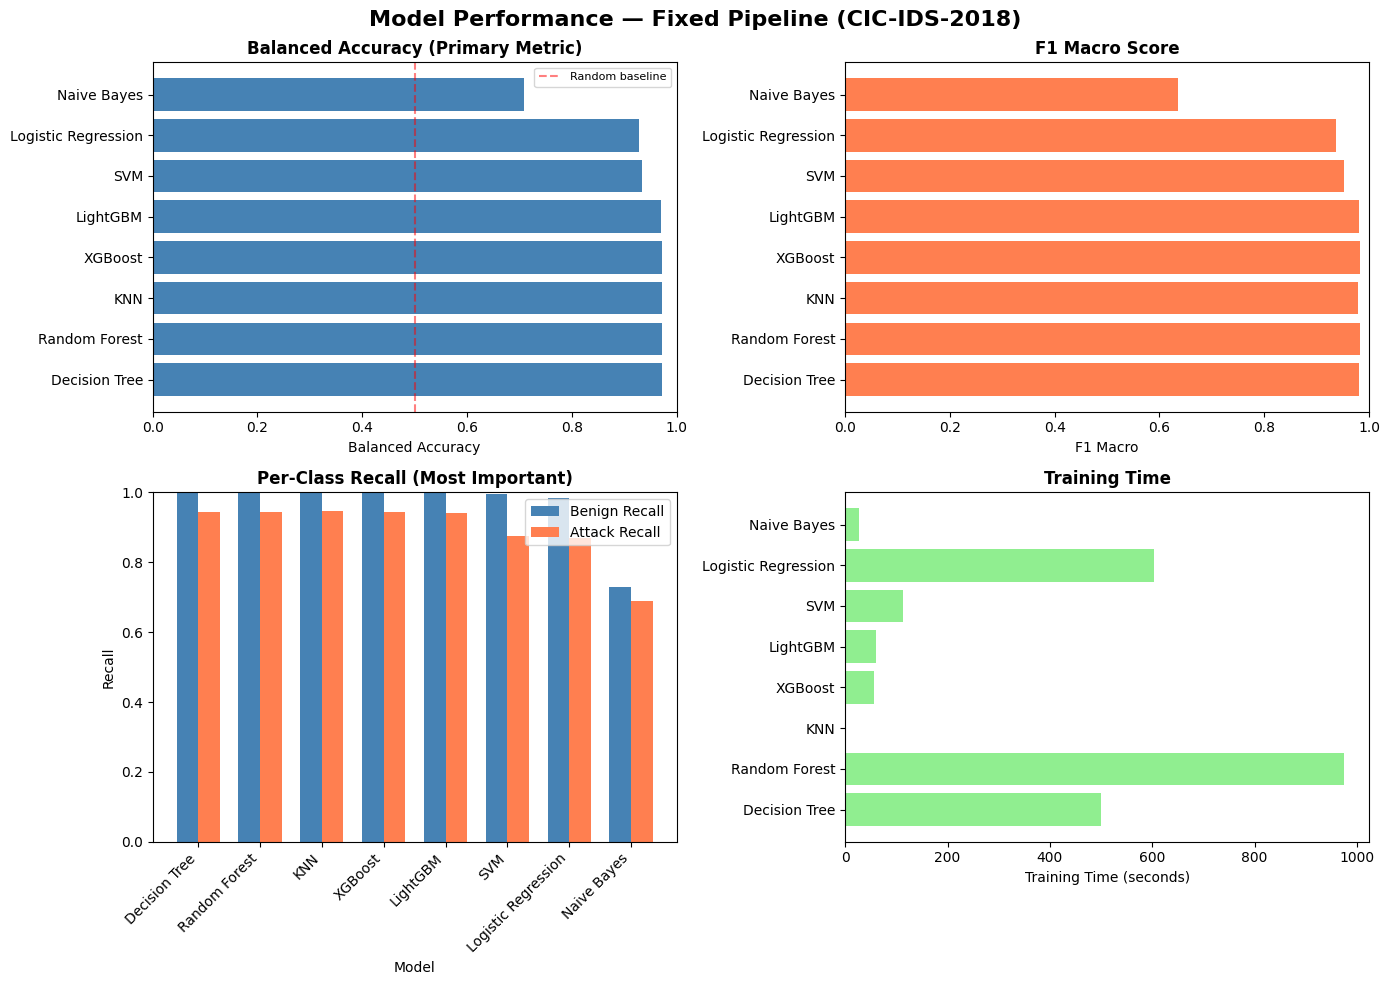

In [15]:
print('\n📊 Creating visualisations...')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance — Fixed Pipeline (CIC-IDS-2018)',
             fontsize=16, fontweight='bold')

model_names = summary_df.index.tolist()

# Balanced Accuracy
axes[0, 0].barh(model_names, summary_df['balanced_accuracy'], color='steelblue')
axes[0, 0].set_xlabel('Balanced Accuracy')
axes[0, 0].set_title('Balanced Accuracy (Primary Metric)', fontweight='bold')
axes[0, 0].set_xlim(0, 1)
axes[0, 0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
axes[0, 0].legend(fontsize=8)

# F1 Macro
axes[0, 1].barh(model_names, summary_df['f1_macro'], color='coral')
axes[0, 1].set_xlabel('F1 Macro')
axes[0, 1].set_title('F1 Macro Score', fontweight='bold')
axes[0, 1].set_xlim(0, 1)

# Per-class Recall
x     = np.arange(len(model_names))
width = 0.35
axes[1, 0].bar(x - width/2, summary_df['benign_recall'], width,
               label='Benign Recall', color='steelblue')
axes[1, 0].bar(x + width/2, summary_df['attack_recall'], width,
               label='Attack Recall', color='coral')
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Per-Class Recall (Most Important)', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(model_names, rotation=45, ha='right')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()

# Training time
axes[1, 1].barh(model_names, summary_df['train_time'], color='lightgreen')
axes[1, 1].set_xlabel('Training Time (seconds)')
axes[1, 1].set_title('Training Time', fontweight='bold')

plt.tight_layout()
plot_path = os.path.join(BASE_MODEL_DIR, 'model_comparison_fixed.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {plot_path}')
plt.show()

## 12. Final Summary

In [17]:
print('\n' + '=' * 80)
print('🎉 TRAINING COMPLETE — FIXED PIPELINE')
print('=' * 80)

print('\n📋 What was fixed in this notebook:')
print('   ✅ Corrupt rows removed  (impossible negative values from CICFlowMeter bug)')
print('   ✅ Scaling done correctly (split first → fit on train only)')
print('   ✅ Honest metrics used   (Balanced Accuracy + per-class Recall)')

print('\n📊 Models Ranked by Balanced Accuracy:')
for rank, (model_name, row) in enumerate(
        sorted(results.items(),
               key=lambda x: x[1]['balanced_accuracy'],
               reverse=True), 1):
    print(f'   {rank}. {model_name:<22}  '
          f'Bal.Acc={row["balanced_accuracy"]:.4f}  '
          f'Benign Recall={row["benign_recall"]:.4f}  '
          f'Attack Recall={row["attack_recall"]:.4f}')

print(f'\n📁 All models saved to: {BASE_MODEL_DIR}')
print('\n💡 Key reminder:')
print('   A good IDS model needs HIGH recall on BOTH classes.')
print('   Low Benign Recall → too many false alarms.')
print('   Low Attack Recall → attacks are slipping through.')


🎉 TRAINING COMPLETE — FIXED PIPELINE

📋 What was fixed in this notebook:
   ✅ Corrupt rows removed  (impossible negative values from CICFlowMeter bug)
   ✅ Scaling done correctly (split first → fit on train only)
   ✅ Honest metrics used   (Balanced Accuracy + per-class Recall)

📊 Models Ranked by Balanced Accuracy:
   1. Decision Tree           Bal.Acc=0.9719  Benign Recall=0.9992  Attack Recall=0.9445
   2. Random Forest           Bal.Acc=0.9716  Benign Recall=0.9995  Attack Recall=0.9437
   3. KNN                     Bal.Acc=0.9716  Benign Recall=0.9975  Attack Recall=0.9457
   4. XGBoost                 Bal.Acc=0.9716  Benign Recall=0.9997  Attack Recall=0.9435
   5. LightGBM                Bal.Acc=0.9709  Benign Recall=0.9997  Attack Recall=0.9421
   6. SVM                     Bal.Acc=0.9346  Benign Recall=0.9943  Attack Recall=0.8748
   7. Logistic Regression     Bal.Acc=0.9276  Benign Recall=0.9847  Attack Recall=0.8705
   8. Naive Bayes             Bal.Acc=0.7092  Benign Recal